In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import tqdm
import sys
import os

In [3]:
sys.path.append(".")

In [4]:
from utils.datasets import SimpleSet, BerlinSparqlBenchmark
from utils.dbs import FusekiDB, QleverDB, BaseDB
from utils.datasets.base_dataset import QUERY_DIFFICULTY, QUERY_TYPE
from pathlib import Path
import numpy as np
from utils.datasets.base_dataset import DataTensor

/home/bkantz/cgv/hereditary/Dense-KG-Vector-DB/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0
2026-03-24 18:55:22,520 - INFO - Loading faiss with AVX512 support.
2026-03-24 18:55:22,521 - INFO - Could not load library with AVX512 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx512'")
2026-03-24 18:55:22,521 - INFO - Loading faiss with AVX2 support.
2026-03-24 18:55:22,521 - INFO - Could not load library with AVX2 support due to:
ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")
2026-03-24 18:55:22,521 - INFO - Loading faiss.
2026-03-24 18:55:22,567 - INFO - Successfully loaded faiss.


In [5]:
powers = np.arange(0, 6)  # extend on a more powerful machine
sizes = 10**powers

In [6]:
datasets: dict[int, BerlinSparqlBenchmark] = {}
raw_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Running BDSDM generation for size {size}...")
    dataset = BerlinSparqlBenchmark(base_dir=Path(f"./data/bsbm_{power}"), n=size)
    dataset.setup()
    datasets[power] = dataset
    raw_sizes[power] = dataset.get_triple_count()

2026-03-24 18:55:22,821 - INFO - Generating BSBM dataset in data/bsbm_0


Running BDSDM generation for size 1...


Unable to find image 'vcity/bsbm:latest' locally
latest: Pulling from vcity/bsbm
b71466b94f26: Pulling fs layer
4ebddd0f2410: Pulling fs layer
488732cd9995: Pulling fs layer
cae6624228d7: Pulling fs layer
a9456c27737e: Pulling fs layer
fb2274e9e4e4: Pulling fs layer
f7130465b486: Pulling fs layer
a9456c27737e: Waiting
fb2274e9e4e4: Waiting
cae6624228d7: Waiting
f7130465b486: Waiting
b71466b94f26: Verifying Checksum
b71466b94f26: Download complete
4ebddd0f2410: Verifying Checksum
4ebddd0f2410: Download complete
b71466b94f26: Pull complete
4ebddd0f2410: Pull complete
cae6624228d7: Verifying Checksum
cae6624228d7: Download complete
a9456c27737e: Verifying Checksum
a9456c27737e: Download complete
fb2274e9e4e4: Verifying Checksum
fb2274e9e4e4: Download complete
f7130465b486: Verifying Checksum
f7130465b486: Download complete
488732cd9995: Verifying Checksum
488732cd9995: Download complete
488732cd9995: Pull complete
cae6624228d7: Pull complete
a9456c27737e: Pull complete
fb2274e9e4e4: Pull 

destination folder: data/./
Reading in titlewords.txt: 89523 words read in.
Reading in titlewords.txt: 89523 words read in.
Reading in givennames.txt: 88799 words read in.

Generating Product Type Hierarchy...
Product Type Hierarchy of depth 2 with 7 Product Types generated.

Generating Product Features...
289 Product Features generated.

Generating Producers and Products...
1 Producers and 1 Products have been generated.

Generating Vendors and their Offers...
1 Vendors and 20 Offers have been generated.

Generating RatingSite Data: Reviewers and Reviews... 
1 Rating Sites with 1 Persons and 10 Reviews have been generated.

1842 triples generated.


2026-03-24 18:55:30,856 - INFO - Generating BSBM dataset in data/bsbm_1


...

Running BDSDM generation for size 1000...
destination folder: data/./
Reading in titlewords.txt: 89523 words read in.
Reading in titlewords.txt: 89523 words read in.
Reading in givennames.txt: 88799 words read in.

Generating Product Type Hierarchy...
Product Type Hierarchy of depth 3 with 151 Product Types generated.

Generating Product Features...
4745 Product Features generated.

Generating Producers and Products...
22 Producers and 1000 Products have been generated.

Generating Vendors and their Offers...
12 Vendors and 20000 Offers have been generated.

Generating RatingSite Data: Reviewers and Reviews... 
1 Rating Sites with 503 Persons and 10000 Reviews have been generated.

371911 triples generated.


2026-03-24 18:55:34,835 - INFO - Generating BSBM dataset in data/bsbm_4


Running BDSDM generation for size 10000...
destination folder: data/./
Reading in titlewords.txt: 89523 words read in.
Reading in titlewords.txt: 89523 words read in.
Reading in givennames.txt: 88799 words read in.

Generating Product Type Hierarchy...
Product Type Hierarchy of depth 3 with 329 Product Types generated.

Generating Product Features...
10519 Product Features generated.

Generating Producers and Products...
206 Producers and 10000 Products have been generated.

Generating Vendors and their Offers...
99 Vendors and 200000 Offers have been generated.

Generating RatingSite Data: Reviewers and Reviews... 
11 Rating Sites with 5102 Persons and 100000 Reviews have been generated.

3534773 triples generated.


2026-03-24 18:55:40,495 - INFO - Generating BSBM dataset in data/bsbm_5


Running BDSDM generation for size 100000...
destination folder: data/./
Reading in titlewords.txt: 89523 words read in.
Reading in titlewords.txt: 89523 words read in.
Reading in givennames.txt: 88799 words read in.

Generating Product Type Hierarchy...
Product Type Hierarchy of depth 4 with 2011 Product Types generated.

Generating Product Features...
47884 Product Features generated.

Generating Producers and Products...
1988 Producers and 100000 Products have been generated.

Generating Vendors and their Offers...
1015 Vendors and 2000000 Offers have been generated.

Generating RatingSite Data: Reviewers and Reviews... 
99 Rating Sites with 51247 Persons and 1000000 Reviews have been generated.

34872182 triples generated.


In [7]:
from sentence_transformers import SentenceTransformer

encoding_model = SentenceTransformer("all-MiniLM-L6-v2")

2026-03-24 18:56:30,767 - INFO - Use pytorch device_name: cpu
2026-03-24 18:56:30,768 - INFO - Load pretrained SentenceTransformer: all-MiniLM-L6-v2


2026-03-24 18:56:30,936 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 18:56:31,066 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/modules.json "HTTP/1.1 200 OK"
2026-03-24 18:56:31,201 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 18:56:31,328 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config_sentence_transformers.json "HTTP/1.1 200 OK"
2026-03-24 18:56:31,460 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Red

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-24 18:56:32,886 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 18:56:32,910 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/c9745ed1d9f207416be6d2e6f8de32d1f16199bf/config.json "HTTP/1.1 200 OK"
2026-03-24 18:56:33,039 - INFO - HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/tokenizer_config.json "HTTP/1.1 307 Temporary Redirect"
2026-03-24 18:56:33,172 - INFO - HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transfor

In [ ]:
encoded_sizes: dict[int, int] = {}
for power, size in zip(powers, sizes):
    print(f"Encoding dataset of size {size}...")
    dataset = datasets[power]
    dataset.encode(encoding_model)
    encoded_sizes[power] = dataset.get_triple_count(encoded=True)

Encoding dataset of size 1...


Encoding triples:   0%|          | 0/1842 [00:00<?, ?it/s]

Encoding triples: 100%|██████████| 1842/1842 [00:05<00:00, 359.59it/s]


Encoding dataset of size 10...


Encoding triples: 100%|██████████| 4987/4987 [00:04<00:00, 1059.59it/s] 


...

Encoding dataset of size 1000...


Encoding triples: 100%|██████████| 371911/371911 [01:41<00:00, 3661.04it/s] 


Encoding dataset of size 10000...


Encoding triples: 100%|██████████| 3534773/3534773 [05:03<00:00, 11636.86it/s] 


Encoding dataset of size 100000...


## BSBM queries

### Simple Use case: 
find 10 products with a specific encoded label


### Complex Use case: 
For a specific product find 10 other similar products via their product label. 


In [ ]:
test_label = "house furniture storage container"
test_tensor = DataTensor.from_numpy(encoding_model.encode(test_label))

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
test_tensor.to_literal().n3()

'"{\\"data\\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436276763677597, -0.028667299076914787, -0.03249424323439598, 0.05894969776272774, -0.0051073539070785046, 0.09506018459796906, -0.02917008101940155, -0.07172351330518723, 0.03642679378390312, 0.017889918759465218, 0.0777449756860733, -0.010582818649709225, -0.027199456468224525, -0.014839813113212585, 0.004996409639716148, -0.05195300653576851, -0.01563340052962303, -0.0004883771180175245, 0.012572054751217365, -0.0434229

In [32]:
base_bsbm_set = datasets[4]
db = QleverDB(
    id="test",
    base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
    dataset=base_bsbm_set,
    use_encoded_ttl=True,
)
# db = FusekiDB(
#     id="test",
#     base_dir=Path(f"./scratch/bsbm/{base_bsbm_set.base_dir.name}"),
#     dataset=base_bsbm_set,
#     build_dir=Path("../jena-datatensor"),
#     do_image_build=False,
#     use_encoded_ttl=True,
# )
possible_queries = db.get_queries(test_tensor)
print(possible_queries)


{<QUERY_DIFFICULTY.EASY: 'easy'>: {<QUERY_TYPE.EMBEDDED: 'embedded'>: '\nPREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>\nPREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>\nPREFIX dtf: <https://w3id.org/rdf-tensor/functions#>\nPREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>\nSELECT ?product  ?vector ?dist\nWHERE {\n?product rdf:label_embedding ?vector .\nBIND(dtf:cosineSimilarity(?vector, "{\\"data\\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436

In [33]:
print(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])


PREFIX dt: <https://w3id.org/rdf-tensor/datatypes#>
PREFIX rdf: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX dtf: <https://w3id.org/rdf-tensor/functions#>
PREFIX bsbmi: <http://www4.wiwiss.fu-berlin.de/bizer/bsbm/v01/instances/>
SELECT ?product  ?vector ?dist
WHERE {
?product rdf:label_embedding ?vector .
BIND(dtf:cosineSimilarity(?vector, "{\"data\": [0.0019237878732383251, 0.0590696819126606, -0.06259280443191528, -0.00878896564245224, 0.08017760515213013, 0.0004897376638837159, 0.04901154339313507, -0.016156308352947235, -0.04537815973162651, 0.011929645203053951, -0.003551354631781578, -0.0034783610608428717, 0.023264393210411072, 0.024490009993314743, -0.023595614358782768, -0.0738239586353302, 0.0142268817871809, -0.00022305142192635685, -0.031117549166083336, 0.07163402438163757, -0.04559386894106865, 0.04442800208926201, 0.00043882164754904807, -0.004044309724122286, 0.05173110216856003, 0.08436276763677597, -0.028667299076914787, -0.03249424323439598, 0.05894969776272774, -

In [34]:
with db:
    possible_queries = db.get_queries(test_tensor)
    results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
results

2026-03-24 16:58:26,967 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-03-24 16:59:02,163 - INFO - Stopping server with container name qlever_benchmarks_test
2026-03-24 16:59:02,203 - ERROR - Command failed with return code 1
2026-03-24 16:59:02,237 - INFO - Starting QLever server with container name qlever_benchmarks_test on port 5031
2026-03-24 16:59:02,238 - INFO - Running command: docker run --name qlever_benchmarks_test -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_4/qlever_db:/data -w /data  qlever:tensors 'qlever-server -i test --port 5030 -k 0'
2026-03-24 16:59:05,291 - INFO - Server is up and responding to queries
2026-03-24 16:59:09,604 - INFO - Stopping server with container name qlever_benchmarks_test


,product,vector,dist
0,bsbmi:dataFromProducer28/Producer28,"{""Data"": [0.03146154433488846, 0.0730304270982...",0.5743878483772
1,bsbmi:dataFromProducer42/Product1985,"{""Data"": [-0.053947802633047104, 0.09995079785...",0.4656712710857
2,bsbmi:ProductFeature8882,"{""Data"": [0.0993858054280281, 0.00443259999155...",0.4550432562828
3,bsbmi:ProductFeature585,"{""Data"": [0.05921391397714615, -0.000105342958...",0.4431591331959
4,bsbmi:dataFromProducer204/Product9871,"{""Data"": [-0.019114747643470764, 0.04421398043...",0.4265949130058
5,bsbmi:dataFromProducer126/Product6035,"{""Data"": [-0.027103513479232788, 0.09437111020...",0.4230343103409
6,bsbmi:ProductFeature4178,"{""Data"": [0.0473283976316452, 0.07827869802713...",0.4190457165241
7,bsbmi:dataFromProducer90/Product4341,"{""Data"": [-0.046234358102083206, 0.02935838326...",0.4177694916725
8,bsbmi:ProductFeature9853,"{""Data"": [0.01419425942003727, -0.001854153466...",0.4172213077545
9,bsbmi:dataFromProducer107/Product5062,"{""Data"": [-0.03348818048834801, 0.051626261323...",0.4087207317352


In [35]:
with db:
    count=db.query("SELECT (COUNT(*) AS ?count) WHERE { ?s ?p ?o }")
print(count)

2026-03-24 16:59:15,346 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-03-24 16:59:15,348 - WARNING - DB directory scratch/bsbm/bsbm_4/qlever_db already exists, removing locks if any
2026-03-24 16:59:15,348 - INFO - Stopping server with container name qlever_benchmarks_test
2026-03-24 16:59:15,415 - ERROR - Command failed with return code 1
2026-03-24 16:59:15,457 - INFO - Starting QLever server with container name qlever_benchmarks_test on port 5031
2026-03-24 16:59:15,460 - INFO - Running command: docker run --name qlever_benchmarks_test -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_4/qlever_db:/data -w /data  qlever:tensors 'qlever-server -i test --port 5030 -k 0'
2026-03-24 16:59:18,507 - INFO - Server is up and responding to queries
2026-03-24 16:59:18,582 - INFO - Stopping server with container name qlever_benchmarks_test


     count
0  3577077


In [40]:
import time

with db:
    possible_queries = db.get_queries(test_tensor)
    timings = []
    for _ in tqdm.tqdm(range(10)):
        start_time = time.time()
        results = db.query(possible_queries[QUERY_DIFFICULTY.EASY][QUERY_TYPE.EMBEDDED])
        elapsed_time = time.time() - start_time
        timings.append(elapsed_time)
print("Median elapsed time:", np.median(timings))
results

2026-03-24 17:00:38,826 - INFO - Loading dataset into QLever server from data/bsbm_4/dataset.nt
2026-03-24 17:00:38,828 - WARNING - DB directory scratch/bsbm/bsbm_4/qlever_db already exists, removing locks if any
2026-03-24 17:00:38,828 - INFO - Stopping server with container name qlever_benchmarks_test
2026-03-24 17:00:38,915 - ERROR - Command failed with return code 1
2026-03-24 17:00:38,939 - INFO - Starting QLever server with container name qlever_benchmarks_test on port 5031
2026-03-24 17:00:38,940 - INFO - Running command: docker run --name qlever_benchmarks_test -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_4/qlever_db:/data -w /data  qlever:tensors 'qlever-server -i test --port 5030 -k 0'
2026-03-24 17:00:41,997 - INFO - Server is up and responding to queries
100%|██████████| 10/10 [00:03<00:00,  2.55it/s]
2026-03-24 17:00:45,924 - INFO - Stopping server with container name qlever_benchmarks_test


Median elapsed time: 0.0067549943923950195


,product,vector,dist
0,bsbmi:dataFromProducer28/Producer28,"{""Data"": [0.03146154433488846, 0.0730304270982...",0.5743878483772
1,bsbmi:dataFromProducer42/Product1985,"{""Data"": [-0.053947802633047104, 0.09995079785...",0.4656712710857
2,bsbmi:ProductFeature8882,"{""Data"": [0.0993858054280281, 0.00443259999155...",0.4550432562828
3,bsbmi:ProductFeature585,"{""Data"": [0.05921391397714615, -0.000105342958...",0.4431591331959
4,bsbmi:dataFromProducer204/Product9871,"{""Data"": [-0.019114747643470764, 0.04421398043...",0.4265949130058
5,bsbmi:dataFromProducer126/Product6035,"{""Data"": [-0.027103513479232788, 0.09437111020...",0.4230343103409
6,bsbmi:ProductFeature4178,"{""Data"": [0.0473283976316452, 0.07827869802713...",0.4190457165241
7,bsbmi:dataFromProducer90/Product4341,"{""Data"": [-0.046234358102083206, 0.02935838326...",0.4177694916725
8,bsbmi:ProductFeature9853,"{""Data"": [0.01419425942003727, -0.001854153466...",0.4172213077545
9,bsbmi:dataFromProducer107/Product5062,"{""Data"": [-0.03348818048834801, 0.051626261323...",0.4087207317352


## Try some timings!

In [ ]:
import timeit
import pandas as pd


def test_db(
    power: int,
    size: int,
    db: BaseDB,
    difficulty=QUERY_DIFFICULTY.EASY,
    query_type=QUERY_TYPE.EMBEDDED,
    repetitions=128,
) -> pd.DataFrame:
    timings = []
    if query_type not in db.get_available_query_types():
        print(f"Query type {query_type} not available for {db.name}, skipping.")
        return pd.DataFrame()
    test_queries = db.get_queries(
        embedding=test_tensor,
    )
    q = test_queries[difficulty][query_type]
    for i in tqdm.tqdm(
        range(repetitions),
        desc=f"Timing for size {size}, difficulty {difficulty.value}, query type {query_type.value}, db {db.name}",
    ):
        start_time = timeit.default_timer()
        try:
            results = db.raw_query(q)
            assert results is not None  and len(results.bindings) > 0, "Query returned no results"
        except Exception as e:
            print(f"Error occurred while querying {db.name}: {e}")
            break
        end_time = timeit.default_timer()
        elapsed_time = end_time - start_time
        timings.append(
            {
                "size": encoded_sizes[power],
                "power": power,
                "estimated_size": size,
                "elapsed_time": elapsed_time,
                "rep": i,
                "engine": db.name,
                "difficulty": difficulty.value,
                "query_type": query_type.value,
            }
        )
        if elapsed_time > 30:
            print(
                f"Warning: Query took {elapsed_time:.2f} seconds on {db.name} for size {size}, difficulty {difficulty.value}, query type {query_type.value}. Will cancel."
            )
            break
    return pd.DataFrame(timings)


timings_df = pd.DataFrame()
for power, size in zip(powers, sizes):
    difficulties = [QUERY_DIFFICULTY.HARD, QUERY_DIFFICULTY.EASY]
    if power > 1:
        difficulties = [QUERY_DIFFICULTY.EASY]
    print(f"Running BDSDM timing for size {size}...")
    dataset = datasets[power]
    dbs: list[BaseDB] = [
        QleverDB(
            id="timing-qlever",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
        FusekiDB(
            id="timing-fuseki",
            base_dir=Path(f"./scratch/bsbm/{dataset.base_dir.name}"),
            build_dir=Path("../jena-datatensor"),
            dataset=dataset,
            use_encoded_ttl=True,
        ),
    ]
    for db in dbs:
        for difficulty in difficulties:
            repetitions = 128 if difficulty == QUERY_DIFFICULTY.EASY else 16
            for query_type in [
                QUERY_TYPE.INDEX,
                QUERY_TYPE.EMBEDDED,
            ]:
                print(
                    f"Testing {db.name} with difficulty {difficulty.value} and query type {query_type.value}..."
                )
                with db:
                    db_timings = test_db(
                        power=power,
                        size=size,
                        db=db,
                        difficulty=difficulty,
                        query_type=query_type,
                        repetitions=repetitions,
                    )
                    timings_df = pd.concat([timings_df, db_timings], ignore_index=True)


2026-03-24 16:30:17,607 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-03-24 16:30:17,608 - WARNING - DB directory scratch/bsbm/bsbm_0/qlever_db already exists, removing locks if any
2026-03-24 16:30:17,608 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-24 16:30:17,636 - ERROR - Command failed with return code 1
2026-03-24 16:30:17,660 - INFO - Starting QLever server with container name qlever_benchmarks_timing-qlever on port 5031
2026-03-24 16:30:17,661 - INFO - Running command: docker run --name qlever_benchmarks_timing-qlever -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benchmarks/scratch/bsbm/bsbm_0/qlever_db:/data -w /data  qlever:tensors 'qlever-server -i timing-qlever --port 5030 -k 0'


Running BDSDM timing for size 1...
Testing QLever (Extended) with difficulty hard and query type index...


2026-03-24 16:30:20,724 - INFO - Server is up and responding to queries
Timing for size 1, difficulty hard, query type index, db QLever (Extended): 100%|██████████| 16/16 [00:00<00:00, 146.23it/s]
2026-03-24 16:30:20,848 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-24 16:30:22,155 - INFO - Loading dataset into QLever server from data/bsbm_0/dataset.nt
2026-03-24 16:30:22,156 - WARNING - DB directory scratch/bsbm/bsbm_0/qlever_db already exists, removing locks if any
2026-03-24 16:30:22,156 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever
2026-03-24 16:30:22,182 - ERROR - Command failed with return code 1
2026-03-24 16:30:22,205 - INFO - Starting QLever server with container name qlever_benchmarks_timing-qlever on port 5031
2026-03-24 16:30:22,207 - INFO - Running command: docker run --name qlever_benchmarks_timing-qlever -e UID=501 -e GID=220 -p 5031:5030 -v /Users/benedikt/tugraz/cgv/hereditary/Dense-KG-Vector-DB/benc

Testing QLever (Extended) with difficulty hard and query type embedded...


2026-03-24 16:30:25,244 - INFO - Server is up and responding to queries
Timing for size 1, difficulty hard, query type embedded, db QLever (Extended):   0%|          | 0/16 [00:00<?, ?it/s]
2026-03-24 16:30:25,356 - INFO - Stopping server with container name qlever_benchmarks_timing-qlever


...

2026-03-24 16:35:00,825 - INFO - Loading dataset into Fuseki server from data/bsbm_4/dataset.nt
2026-03-24 16:36:04,095 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki
2026-03-24 16:36:04,147 - ERROR - Command failed with return code 1
2026-03-24 16:36:04,175 - INFO - Starting Fuseki server with container name fuseki_benchmarks_timing-fuseki on port 3031
2026-03-24 16:36:06,352 - INFO - Server is up and responding to queries
2026-03-24 16:36:06,361 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki


Query type QUERY_TYPE.INDEX not available for FusekiDB + RDFTensor, skipping.


2026-03-24 16:36:07,040 - INFO - Building docker image jena-datatensor from ../jena-datatensor
2026-03-24 16:36:07,040 - INFO - Building docker image jena-datatensor from ../jena-datatensor


Testing FusekiDB + RDFTensor with difficulty easy and query type embedded...


2026-03-24 16:36:07,768 - INFO - Loading dataset into Fuseki server from data/bsbm_4/dataset.nt
2026-03-24 16:37:02,806 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki
2026-03-24 16:37:02,870 - ERROR - Command failed with return code 1
2026-03-24 16:37:02,944 - INFO - Starting Fuseki server with container name fuseki_benchmarks_timing-fuseki on port 3031
2026-03-24 16:37:04,388 - INFO - Server is up and responding to queries
Timing for size 10000, difficulty easy, query type embedded, db FusekiDB + RDFTensor: 100%|██████████| 128/128 [01:03<00:00,  2.01it/s]
2026-03-24 16:38:08,217 - INFO - Stopping server with container name fuseki_benchmarks_timing-fuseki


In [19]:
db.get_queries(test_tensor)[QUERY_DIFFICULTY.EASY].keys()

dict_keys([<QUERY_TYPE.EMBEDDED: 'embedded'>, <QUERY_TYPE.TWO_STAGE: 'two_stage'>])

In [20]:
timings_df.to_csv("./scratch/bdsdm_timings.csv", index=False)
timings_df["engine"].unique()

<StringArray>
['QLever (Extended)', 'FusekiDB + RDFTensor']
Length: 2, dtype: str

In [21]:
engines = timings_df["engine"].unique()
difficulties = timings_df["difficulty"].unique()

In [22]:
groupings = timings_df.groupby(["size", "engine", "difficulty", "query_type"])[
    "elapsed_time"
]
quantiles = [0.05, 0.95]
median_timings = groupings.median().reset_index()
quantile_timings = groupings.quantile(quantiles).unstack().reset_index()

In [23]:
median_timings

,size,engine,difficulty,query_type,elapsed_time
0,1,FusekiDB + RDFTensor,easy,embedded,0.015666
1,1,QLever (Extended),easy,embedded,0.003284
2,1,QLever (Extended),easy,index,0.003753
3,1,QLever (Extended),hard,index,0.005002
4,10,FusekiDB + RDFTensor,easy,embedded,0.015019
5,10,FusekiDB + RDFTensor,hard,embedded,0.944517
6,10,QLever (Extended),easy,embedded,0.003473
7,10,QLever (Extended),easy,index,0.003514
8,10,QLever (Extended),hard,embedded,0.004969
9,10,QLever (Extended),hard,index,0.004896


In [24]:
colors = {eng: color for eng, color in zip(engines, ["C0", "C1", "C2", "C3", "C4"])}
colors

{'QLever (Extended)': 'C0', 'FusekiDB + RDFTensor': 'C1'}

/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_87465/3236174822.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_87465/3236174822.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_87465/3236174822.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(
/var/folders/w0/5b7f2srd2sb_56zjv17vqnym0000gn/T/ipykernel_87465/3236174822.py:22: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "o-" (-> linestyle='-'). Th

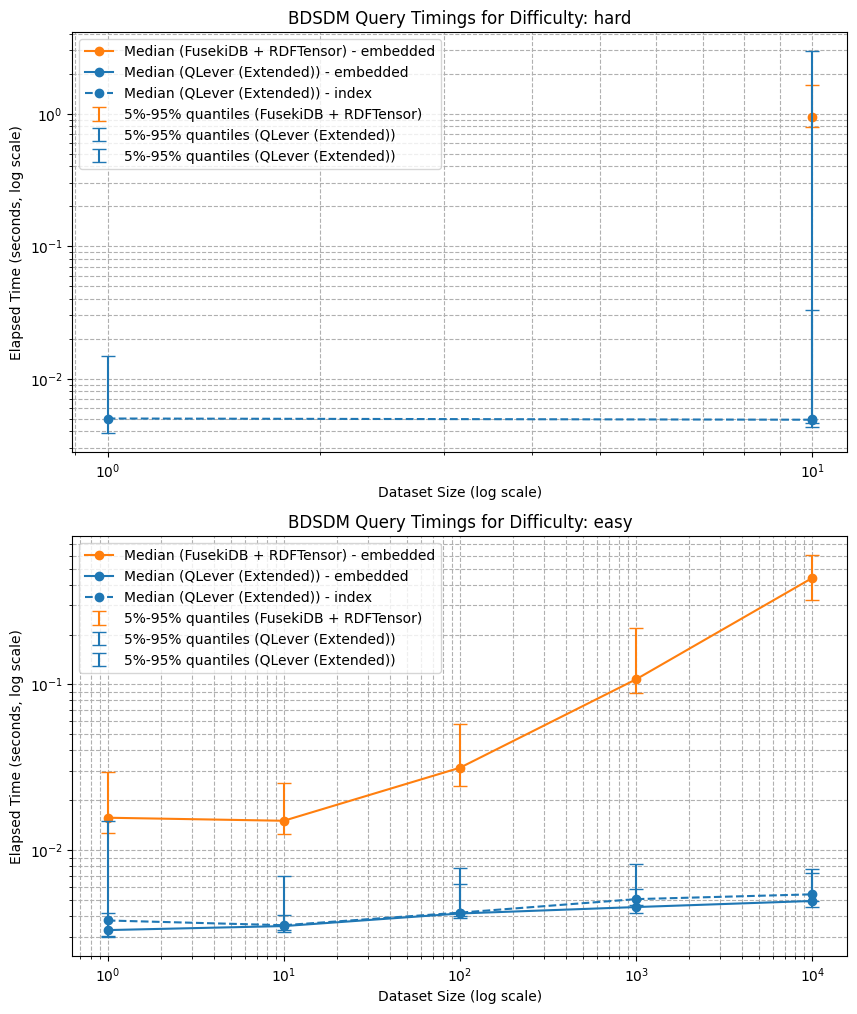

In [25]:
import matplotlib.pyplot as plt


# plot the timings as double-log plot with error bars for the 5% and 95% quantiles
def plot_timings(ax, median_timings, quantile_timings, engine, difficulty):
    for query_type in QUERY_TYPE:
        for engine in median_timings["engine"].unique():
            engine_median = median_timings[
                (median_timings["query_type"] == query_type.value)
                & (median_timings["difficulty"] == difficulty)
                & (median_timings["engine"] == engine)
            ]
            engine_quantiles = quantile_timings[
                (quantile_timings["query_type"] == query_type.value)
                & (quantile_timings["difficulty"] == difficulty)
                & (quantile_timings["engine"] == engine)
            ]
            if engine_median.empty or engine_quantiles.empty:
                continue
            # index are dashed, embedded are solid
            linestyle = "--" if query_type == QUERY_TYPE.INDEX else "-"
            ax.plot(
                engine_median["size"],
                engine_median["elapsed_time"],
                "o-",
                linestyle=linestyle,
                label=f"Median ({engine}) - {query_type.value}",
                color=colors[engine],
            )
            ax.errorbar(
                engine_median["size"],
                engine_median["elapsed_time"],
                yerr=[
                    engine_median["elapsed_time"] - engine_quantiles[0.05],
                    engine_quantiles[0.95] - engine_median["elapsed_time"],
                ],
                barsabove=True,
                capsize=5,
                fmt="none",
                label=f"5%-95% quantiles ({engine})",
                color=colors[engine],
            )


fig, axes = plt.subplots(len(difficulties), 1, figsize=(10, 6 * len(difficulties)))
for i, difficulty in enumerate(difficulties):
    ax = axes[i]
    # set the subtitle to the difficulty

    plot_timings(ax, median_timings, quantile_timings, engines, difficulty)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Dataset Size (log scale)")
    ax.set_ylabel("Elapsed Time (seconds, log scale)")
    ax.set_title(f"BDSDM Query Timings for Difficulty: {difficulty}")
    ax.legend()
    ax.grid(True, which="both", ls="--")
plt.savefig("./scratch/bdsdm_timings.png")
plt.show()

In [26]:
import numpy as np
import faiss

N = 10000
quantizer = faiss.IndexFlatIP(N)  # the other index
index = faiss.IndexIVFFlat(quantizer, N, 100)
data = []
for i in range(N):
    vec = np.zeros(N, dtype=np.float32) + 0.001 * np.random.rand(N)
    vec[i] = 1.0
    data.append(vec)
data = np.array(data)
index.train(data)
index.add(data)

In [27]:
query_vec = np.zeros(N, dtype=np.float32)
query_vec[12] = 1.0
D, I = index.search(query_vec[None, :], 100)
print("Distances:", D)
print("Indices:", I)

Distances: [[0.00334409 2.0013294  2.0013456  2.0013587  2.0013864  2.0013967
  2.0014403  2.001448   2.0014603  2.001493   2.001494   2.0014982
  2.0015168  2.0015302  2.0015624  2.0015633  2.0015686  2.00162
  2.001625   2.0016418  2.0016465  2.0016527  2.0016606  2.001687
  2.0016973  2.0017102  2.0017114  2.0017352  2.0017376  2.0017383
  2.001806   2.0018067  2.0018392  2.0018516  2.0018554  2.0018783
  2.0018864  2.0018933  2.0018942  2.0019245  2.0019312  2.0019438
  2.0019631  2.001964   2.0019727  2.0020366  2.0020516  2.002059
  2.0020745  2.002081   2.0020893  2.002124   2.0021417  2.0021632
  2.00219    2.0021968  2.0022275  2.00223    2.0022318  2.002242
  2.0022457  2.002248   2.0022888  2.0022984  2.0022998  2.0023062
  2.0023408  2.00236    2.0023608  2.0023642  2.0023665  2.0023918
  2.002412   2.002434   2.0024385  2.0024424  2.0024424  2.0025005
  2.0025434  2.002547   2.0025501  2.0025568  2.0025716  2.0025926
  2.002597   2.0026052  2.002614   2.0026255  2.0026276 